# Evaluate structures and sequences versus sequences only

In this notebook, we assess the benefit of including the structural maps to training performance of the machine learning model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.metrics import roc_auc_score

In [ ]:
model_types = ('', 'sequence_only')
data_splits = ('random', 'peptide', 'pMHC')

In [3]:
predictions = []
for data_split in data_splits:
    sequences = pd.read_csv(f'data/interim/sequences_{data_split}_split.csv', index_col='index')

    for model_type in model_types:
        prediction = pd.read_csv(
            f"data/processed/TCRStructMap_{model_type + '_' if model_type else model_type}predictions_on_sequences_"
            f'{data_split}_split.csv'
        )

        prediction['data_split'] = data_split
        prediction['model_type'] = model_type

        prediction = prediction.merge(sequences, how='left', left_on='index', right_index=True)
        prediction = prediction[prediction['sub_model_number'] == prediction['fold']].reset_index(drop=True)

        predictions.append(prediction)

predictions = pd.concat(predictions).reset_index(drop=True)

In [4]:
NUM_SAMPLES = 25
SAMPLE_SIZE = 500

indices = predictions['index'].unique()
rng = np.random.default_rng(123)

samples_metric_scores = []
for sample_num in range(1, NUM_SAMPLES + 1):
    sample_indices = rng.choice(indices, SAMPLE_SIZE)

    sample = predictions[predictions['index'].isin(sample_indices)]

    for (data_split, model_type), group in sample.groupby(['data_split', 'model_type'], dropna=False):
        score = roc_auc_score(group['label'], group['prediction'])
        samples_metric_scores.append(
            {
                'sample_num': sample_num,
                'data_split': data_split,
                'model_type': model_type,
                'roc_auc_score': score,
            }
        )

samples_metric_scores = pd.DataFrame(samples_metric_scores)

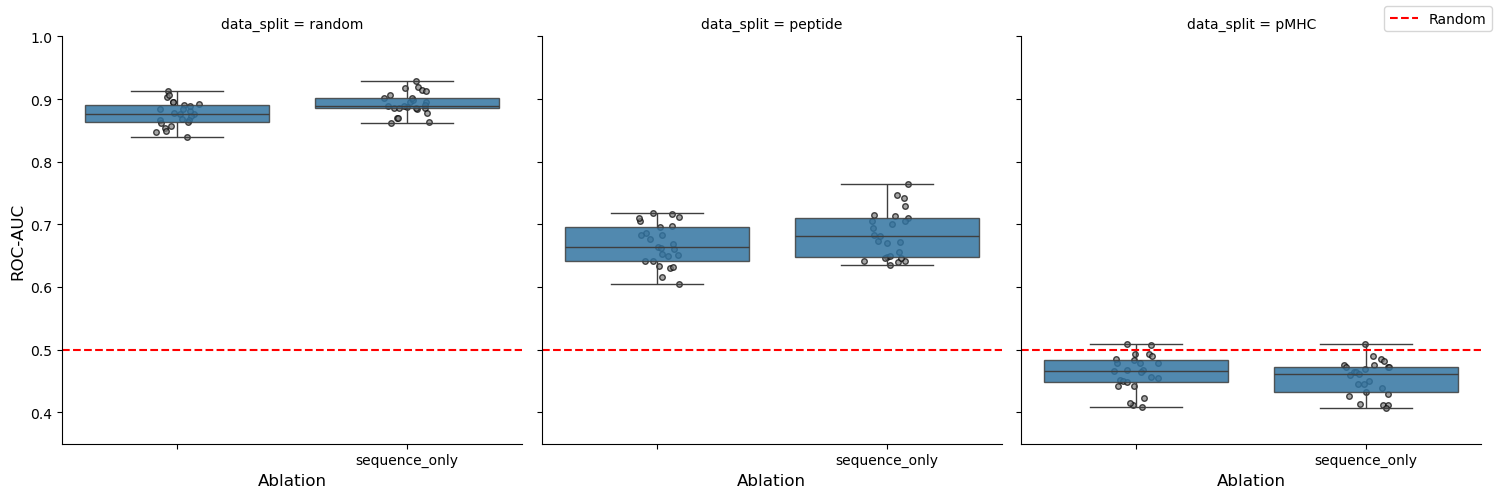

In [5]:
grid = sns.FacetGrid(samples_metric_scores, col='data_split', col_order=data_splits, sharex=False, height=5)

grid.map_dataframe(
    sns.boxplot,
    x='model_type',
    y='roc_auc_score',
    order=model_types,
    showfliers=False,
    boxprops={'alpha': 0.85},
    zorder=1,
)
grid.map_dataframe(
    sns.stripplot,
    x='model_type',
    y='roc_auc_score',
    order=model_types,
    color='grey',
    marker='o',
    size=4,
    edgecolor='black',
    linewidth=1,
    alpha=0.70,
    zorder=0,
)

grid.refline(y=0.5, color='red')
refline_handle = Line2D([0], [0], color='red', linestyle='--', label='Random')
grid.figure.legend(handles=[refline_handle], loc='upper right')

grid.set(ylim=(0.35, 1.0))
grid.set_axis_labels('Ablation', 'ROC-AUC', fontsize=12)

plt.savefig('report/figures/evaluate_structure_vs_sequence.svg')
plt.show()

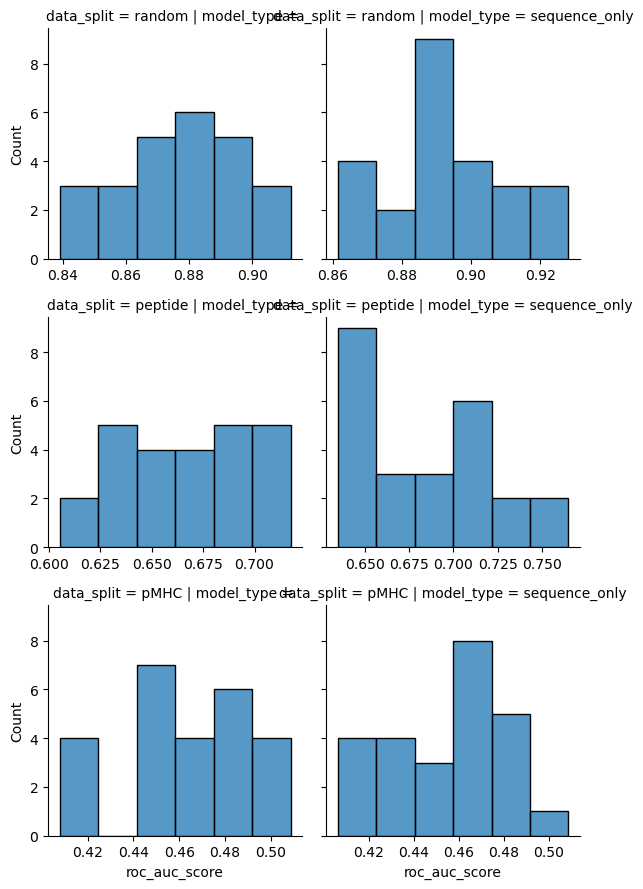

In [6]:
grid = sns.FacetGrid(
    samples_metric_scores,
    row='data_split',
    col='model_type',
    row_order=data_splits,
    col_order=model_types,
    sharex=False,
)
grid.map_dataframe(sns.histplot, x='roc_auc_score')

plt.show()

In [7]:
for data_split, data_group in samples_metric_scores.set_index('sample_num').sort_index().groupby('data_split'):
    print(data_split)
    print(
        stats.ttest_rel(
            data_group.query("model_type == ''")['roc_auc_score'],
            data_group.query("model_type == 'sequence_only'")['roc_auc_score'],
            alternative='greater',
        )
    )

    print()

pMHC
TtestResult(statistic=np.float64(1.6618312042572743), pvalue=np.float64(0.05477749789027123), df=np.int64(24))

peptide
TtestResult(statistic=np.float64(-3.1994976567218476), pvalue=np.float64(0.9980773200957815), df=np.int64(24))

random
TtestResult(statistic=np.float64(-5.46004320840954), pvalue=np.float64(0.999993485175593), df=np.int64(24))

